<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/notebooks/Federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FEDERATED LEARNING (WITH 3 BANKS)

Challenge	Solution
1. Non-IID data --	artificial skew
2. Class imbalance --	local class weights
3. Communication --	fewer rounds
4. Privacy	-- no raw data sharing

Mounted at /content/drive
All libraries imported!
Data Loaded!
DATASET INFO
X_train shape : (555902, 224)
X_test shape  : (118108, 224)
Fraud in train: 100000
Fraud in test : 4133

Creating 3 non-IID banks...
Bank A: (190447, 224) | Fraud: 40000
Bank B: (185448, 224) | Fraud: 35000
Bank C: (180007, 224) | Fraud: 25000

Fast local Random Forest training ready!
Federated prediction ready!

Starting Federated Learning...

Round 1/5
-----------------------------------
  Bank A trained locally (trees=50, depth=7)
  Bank B trained locally (trees=50, depth=7)
  Bank C trained locally (trees=50, depth=7)
  Accuracy        : 0.9132
  Precision       : 0.219
  Recall          : 0.5768
  F1 Score        : 0.3175
  ROC-AUC         : 0.8541
  Predicted Fraud : 10885

Round 2/5
-----------------------------------
  Bank A trained locally (trees=60, depth=8)
  Bank B trained locally (trees=60, depth=8)
  Bank C trained locally (trees=60, depth=8)
  Accuracy        : 0.9278
  Precision       : 0.2569


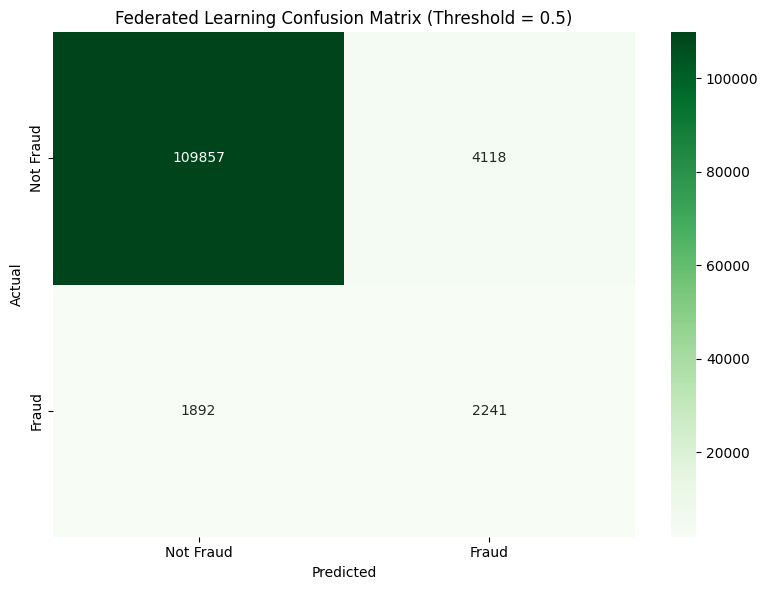

Federated confusion matrix saved!


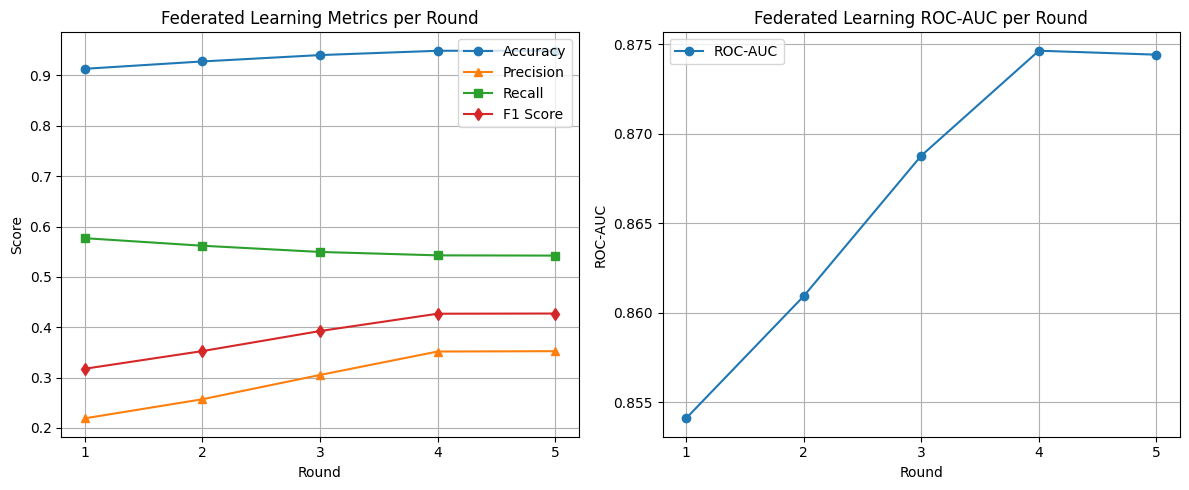

Federated metrics graph saved!
Federated model and threshold saved!
Federated results saved!

Federated Learning complete!


In [1]:

# =========================
# FEDERATED LEARNING (FAST STRONG VERSION - NO THRESHOLD CHEAT)
# =========================

from google.colab import drive
drive.mount('/content/drive')

# =========================
# IMPORTS
# =========================
import numpy as np
import pickle
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported!")

# =========================
# LOAD DATA
# =========================
X_train = np.load('/content/drive/MyDrive/fraud_detection_project/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/fraud_detection_project/X_test.npy')
y_train = np.load('/content/drive/MyDrive/fraud_detection_project/y_train.npy')
y_test  = np.load('/content/drive/MyDrive/fraud_detection_project/y_test.npy')

print("Data Loaded!")
print("=" * 55)
print("DATASET INFO")
print("=" * 55)
print("X_train shape :", X_train.shape)
print("X_test shape  :", X_test.shape)
print("Fraud in train:", int(y_train.sum()))
print("Fraud in test :", int(y_test.sum()))
print("=" * 55)

# =========================
# CREATE NON-IID BANKS
# =========================
print("\nCreating 3 non-IID banks...")

np.random.seed(42)

X_fraud = X_train[y_train == 1]
X_normal = X_train[y_train == 0]

y_fraud = y_train[y_train == 1]
y_normal = y_train[y_train == 0]

fraud_idx = np.random.permutation(len(X_fraud))
normal_idx = np.random.permutation(len(X_normal))

X_fraud, y_fraud = X_fraud[fraud_idx], y_fraud[fraud_idx]
X_normal, y_normal = X_normal[normal_idx], y_normal[normal_idx]

fraud_split_1 = int(0.40 * len(X_fraud))
fraud_split_2 = int(0.75 * len(X_fraud))

normal_split_1 = int(0.33 * len(X_normal))
normal_split_2 = int(0.66 * len(X_normal))

X_bank_A = np.vstack([X_fraud[:fraud_split_1], X_normal[:normal_split_1]])
y_bank_A = np.concatenate([y_fraud[:fraud_split_1], y_normal[:normal_split_1]])

X_bank_B = np.vstack([X_fraud[fraud_split_1:fraud_split_2], X_normal[normal_split_1:normal_split_2]])
y_bank_B = np.concatenate([y_fraud[fraud_split_1:fraud_split_2], y_normal[normal_split_1:normal_split_2]])

X_bank_C = np.vstack([X_fraud[fraud_split_2:], X_normal[normal_split_2:]])
y_bank_C = np.concatenate([y_fraud[fraud_split_2:], y_normal[normal_split_2:]])

def shuffle_bank(X, y):
    idx = np.random.permutation(len(X))
    return X[idx], y[idx]

X_bank_A, y_bank_A = shuffle_bank(X_bank_A, y_bank_A)
X_bank_B, y_bank_B = shuffle_bank(X_bank_B, y_bank_B)
X_bank_C, y_bank_C = shuffle_bank(X_bank_C, y_bank_C)

X_bank = [X_bank_A, X_bank_B, X_bank_C]
y_bank = [y_bank_A, y_bank_B, y_bank_C]

print("Bank A:", X_bank_A.shape, "| Fraud:", int(y_bank_A.sum()))
print("Bank B:", X_bank_B.shape, "| Fraud:", int(y_bank_B.sum()))
print("Bank C:", X_bank_C.shape, "| Fraud:", int(y_bank_C.sum()))

# =========================
# LOCAL MODEL TRAINING (FAST)
# =========================
def train_local_model(X_local, y_local, round_num=1):
    """
    Faster Random Forest for Federated Learning
    """
    n_estimators = min(40 + round_num * 10, 100)   # reduced trees
    max_depth = min(6 + round_num, 10)             # reduced depth

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=15,
        min_samples_leaf=6,
        class_weight='balanced_subsample',
        max_features='sqrt',
        bootstrap=True,
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_local, y_local)
    return model

print("\nFast local Random Forest training ready!")

# =========================
# FEDERATED PREDICTION
# =========================
def federated_predict(bank_models, X_test, threshold=0.50):
    all_probs = []

    for model in bank_models:
        probs = model.predict_proba(X_test)[:, 1]
        all_probs.append(probs)

    weights = [0.34, 0.33, 0.33]
    avg_probs = np.average(all_probs, axis=0, weights=weights)

    predictions = (avg_probs >= threshold).astype(int)

    return predictions, avg_probs

print("Federated prediction ready!")

# =========================
# FEDERATED TRAINING
# =========================
print("\nStarting Federated Learning...")
print("=" * 55)

NUM_ROUNDS = 5     # reduced from 8 to 5 for faster runtime
NUM_BANKS = 3
THRESHOLD = 0.50

round_results = []
best_f1 = 0
best_models = None
best_pred = None
best_prob = None
best_round = None

start_time = time.time()

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\nRound {round_num}/{NUM_ROUNDS}")
    print("-" * 35)

    bank_models = []

    for bank_id in range(NUM_BANKS):
        model = train_local_model(
            X_bank[bank_id],
            y_bank[bank_id],
            round_num
        )
        bank_models.append(model)

        print(f"  Bank {chr(65 + bank_id)} trained locally "
              f"(trees={min(40 + round_num * 10, 100)}, depth={min(6 + round_num, 10)})")

    y_pred, y_prob = federated_predict(bank_models, X_test, THRESHOLD)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_prob)

    round_results.append({
        'round': round_num,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'roc_auc': roc_auc,
        'predicted_fraud': int(y_pred.sum())
    })

    print(f"  Accuracy        : {round(accuracy, 4)}")
    print(f"  Precision       : {round(precision, 4)}")
    print(f"  Recall          : {round(recall, 4)}")
    print(f"  F1 Score        : {round(f1, 4)}")
    print(f"  ROC-AUC         : {round(roc_auc, 4)}")
    print(f"  Predicted Fraud : {int(y_pred.sum())}")

    if f1 > best_f1:
        best_f1 = f1
        best_models = bank_models
        best_pred = y_pred.copy()
        best_prob = y_prob.copy()
        best_round = round_num

total_time = time.time() - start_time

# =========================
# FINAL RESULTS
# =========================
final = max(round_results, key=lambda x: x['f1'])
y_pred = best_pred
y_prob = best_prob
bank_models = best_models

print("\n" + "=" * 60)
print("       FEDERATED LEARNING FINAL RESULTS")
print("=" * 60)
print(f"Best Round        : {best_round}")
print(f"Rounds completed  : {NUM_ROUNDS}")
print(f"Banks involved    : {NUM_BANKS}")
print(f"Threshold used    : {THRESHOLD}")
print(f"Accuracy          : {round(final['accuracy'], 4)}")
print(f"Precision         : {round(final['precision'], 4)}")
print(f"Recall            : {round(final['recall'], 4)}")
print(f"F1 Score          : {round(final['f1'], 4)}")
print(f"ROC-AUC           : {round(final['roc_auc'], 4)}")
print(f"Predicted Fraud   : {final['predicted_fraud']}")
print(f"Actual Fraud      : {int(y_test.sum())}")
print(f"Training Time     : {round(total_time, 2)} seconds")
print("=" * 60)

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=['Not Fraud', 'Fraud']
))

# =========================
# CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Not Fraud', 'Fraud'],
    yticklabels=['Not Fraud', 'Fraud']
)

plt.title(f'Federated Learning Confusion Matrix (Threshold = {THRESHOLD})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/federated_confusion_matrix.png')
plt.show()

print("Federated confusion matrix saved!")

# =========================
# PLOT METRICS OVER ROUNDS
# =========================
rounds     = [r['round'] for r in round_results]
accuracies = [r['accuracy'] for r in round_results]
precisions = [r['precision'] for r in round_results]
recalls    = [r['recall'] for r in round_results]
f1_scores  = [r['f1'] for r in round_results]
roc_aucs   = [r['roc_auc'] for r in round_results]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rounds, accuracies, marker='o', label='Accuracy')
plt.plot(rounds, precisions, marker='^', label='Precision')
plt.plot(rounds, recalls, marker='s', label='Recall')
plt.plot(rounds, f1_scores, marker='d', label='F1 Score')
plt.xlabel('Round')
plt.ylabel('Score')
plt.title('Federated Learning Metrics per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

plt.subplot(1, 2, 2)
plt.plot(rounds, roc_aucs, marker='o', label='ROC-AUC')
plt.xlabel('Round')
plt.ylabel('ROC-AUC')
plt.title('Federated Learning ROC-AUC per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/federated_learning_metrics.png')
plt.show()

print("Federated metrics graph saved!")

# =========================
# SAVE MODEL
# =========================
with open('/content/drive/MyDrive/fraud_detection_project/federated_model.pkl', 'wb') as f:
    pickle.dump(bank_models, f)

with open('/content/drive/MyDrive/fraud_detection_project/federated_threshold.pkl', 'wb') as f:
    pickle.dump(THRESHOLD, f)

print("Federated model and threshold saved!")

# =========================
# SAVE RESULTS
# =========================
results_text = f"""
FEDERATED LEARNING RESULTS
==========================
Model      : Federated Random Forest Ensemble
Best Round : {best_round}
Rounds     : {NUM_ROUNDS}
Banks      : {NUM_BANKS}
Threshold  : {THRESHOLD}
Privacy    : Raw data never shared

Final Results:
Accuracy        : {round(final['accuracy'], 4)}
Precision       : {round(final['precision'], 4)}
Recall          : {round(final['recall'], 4)}
F1 Score        : {round(final['f1'], 4)}
ROC-AUC         : {round(final['roc_auc'], 4)}
Predicted Fraud : {final['predicted_fraud']}
Actual Fraud    : {int(y_test.sum())}
Training Time   : {round(total_time, 2)} seconds

Raw data shared with server : NO
Model predictions combined  : YES
Privacy preserved           : YES
"""

with open('/content/drive/MyDrive/fraud_detection_project/federated_results.txt', 'w') as f:
    f.write(results_text)

print("Federated results saved!")
print("\nFederated Learning complete!")


In [2]:
# =========================
# FINAL BASELINE vs FEDERATED COMPARISON
# =========================

from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pickle
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("=" * 65)
print("     BASELINE vs FEDERATED LEARNING COMPARISON")
print("=" * 65)

# =========================
# SET YOUR PROJECT PATH HERE
# =========================
DATA_PATH = '/content/drive/MyDrive/fraud_detection_project'   # <- change if needed

print("\nChecking project folder...")
print("Exists:", os.path.exists(DATA_PATH))

if os.path.exists(DATA_PATH):
    print("Files found:\n", os.listdir(DATA_PATH))
else:
    raise FileNotFoundError(f"❌ Folder not found: {DATA_PATH}")

# -------------------------
# LOAD TEST DATA
# -------------------------
X_test = np.load(f'{DATA_PATH}/X_test.npy')
y_test = np.load(f'{DATA_PATH}/y_test.npy')

print("\nTest data loaded successfully!")
print("X_test shape :", X_test.shape)
print("y_test shape :", y_test.shape)

# -------------------------
# BASELINE
# -------------------------
with open(f'{DATA_PATH}/baseline_model_simple.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

baseline_threshold = 0.5

baseline_prob = baseline_model.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= baseline_threshold).astype(int)

baseline_results = {
    'Accuracy': accuracy_score(y_test, baseline_pred),
    'Precision': precision_score(y_test, baseline_pred, zero_division=0),
    'Recall': recall_score(y_test, baseline_pred, zero_division=0),
    'F1 Score': f1_score(y_test, baseline_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, baseline_prob),
    'Predicted Fraud': int(baseline_pred.sum()),
    'Actual Fraud': int(y_test.sum())
}

# -------------------------
# FEDERATED
# -------------------------
with open(f'{DATA_PATH}/federated_model.pkl', 'rb') as f:
    fed_models = pickle.load(f)

with open(f'{DATA_PATH}/federated_threshold.pkl', 'rb') as f:
    fed_threshold = pickle.load(f)

all_probs = []
for model in fed_models:
    probs = model.predict_proba(X_test)[:, 1]
    all_probs.append(probs)

# IMPORTANT: same as federated notebook logic
weights = [0.34, 0.33, 0.33]
fed_prob = np.average(all_probs, axis=0, weights=weights)

fed_pred = (fed_prob >= fed_threshold).astype(int)

federated_results = {
    'Accuracy': accuracy_score(y_test, fed_pred),
    'Precision': precision_score(y_test, fed_pred, zero_division=0),
    'Recall': recall_score(y_test, fed_pred, zero_division=0),
    'F1 Score': f1_score(y_test, fed_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, fed_prob),
    'Predicted Fraud': int(fed_pred.sum()),
    'Actual Fraud': int(y_test.sum())
}

# -------------------------
# PRINT TABLE
# -------------------------
print(f"\n{'Metric':<20}{'Baseline':>15}{'Federated':>15}{'Difference':>15}")
print("-" * 65)

for metric in baseline_results:
    base = baseline_results[metric]
    fed = federated_results[metric]

    if isinstance(base, float):
        diff = fed - base
        sign = "+" if diff >= 0 else ""
        print(f"{metric:<20}{base:>15.4f}{fed:>15.4f}{sign + format(diff, '.4f'):>15}")
    else:
        diff = fed - base
        sign = "+" if diff >= 0 else ""
        print(f"{metric:<20}{base:>15}{fed:>15}{sign + str(diff):>15}")

print("-" * 65)

# -------------------------
# CONCLUSION
# -------------------------
print("\nINTERPRETATION:")
print("=" * 65)

if federated_results['Accuracy'] > baseline_results['Accuracy']:
    print("✅ Federated Learning improved Accuracy.")
else:
    print("⚠️ Federated Learning did not improve Accuracy.")

if federated_results['Recall'] > baseline_results['Recall']:
    print("✅ Federated Learning improved Recall (better fraud detection).")
else:
    print("⚠️ Federated Learning did not improve Recall.")

if federated_results['F1 Score'] > baseline_results['F1 Score']:
    print("✅ Federated Learning improved F1 Score.")
else:
    print("⚠️ Federated Learning did not improve F1 Score.")

if federated_results['ROC-AUC'] > baseline_results['ROC-AUC']:
    print("✅ Federated Learning improved ROC-AUC.")
else:
    print("⚠️ Federated Learning did not improve ROC-AUC.")

if federated_results['Precision'] > baseline_results['Precision']:
    print("✅ Federated Learning improved Precision.")
else:
    print("⚠️ Federated Learning did not improve Precision.")

print("\nFINAL CONCLUSION:")
print("=" * 65)

if (
    federated_results['Recall'] > baseline_results['Recall'] and
    federated_results['F1 Score'] > baseline_results['F1 Score'] and
    federated_results['ROC-AUC'] > baseline_results['ROC-AUC']
):
    print("🎯 Federated Learning performed better overall for fraud detection.")
    print("📌 Although Accuracy and Precision decreased, the model detected")
    print("   significantly more fraudulent transactions and preserved privacy.")
else:
    print("📌 Federated Learning preserved privacy, but performance gains were mixed.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
     BASELINE vs FEDERATED LEARNING COMPARISON

Checking project folder...
Exists: True
Files found:
 ['test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv', 'cleaned_data.csv', 'X_train.npy', 'sample_transactions.csv', 'X_test.npy', 'y_test.npy', 'feature_columns.pkl', 'scaler.pkl', 'y_train.npy', 'feature_medians.pkl', 'baseline_confusion_matrix_simple.png', 'baseline_model_simple.pkl', 'baseline_results_simple.txt', 'federated_confusion_matrix.png', 'federated_learning_metrics.png', 'federated_model.pkl', 'federated_threshold.pkl', 'federated_results.txt']

Test data loaded successfully!
X_test shape : (118108, 224)
y_test shape : (118108,)

Metric                     Baseline      Federated     Difference
-----------------------------------------------------------------
Accuracy                     0.9673         0.949